In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Evaluation libraries imported successfully!")

Evaluation libraries imported successfully!


In [2]:
np.random.seed(42)

n = 2000

data = pd.DataFrame({
    "transaction_amount": np.random.randint(100, 50000, n),
    "transaction_frequency": np.random.randint(1, 20, n),
    "account_age_days": np.random.randint(30, 3000, n),
    "international": np.random.randint(0, 2, n),
    "failed_attempts": np.random.randint(0, 6, n)
})

data["fraud"] = (
    ((data["transaction_amount"] > 30000) &
     (data["failed_attempts"] >= 3)) |
    ((data["international"] == 1) &
     (data["transaction_frequency"] > 12))
).astype(int)

noise = np.random.choice(n, size=120, replace=False)
data.loc[noise, "fraud"] = 1 - data.loc[noise, "fraud"]

X = data.drop("fraud", axis=1)
y = data["fraud"]

print("Dataset shape:", data.shape)
print("\nFraud counts:")
print(y.value_counts())

Dataset shape: (2000, 6)

Fraud counts:
fraud
0    1269
1     731
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 1600
Testing samples: 400

Training class distribution:
fraud
0    1015
1     585
Name: count, dtype: int64

Testing class distribution:
fraud
0    254
1    146
Name: count, dtype: int64


In [4]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost model trained successfully!")
print("Predictions generated:", len(y_pred_xgb))

XGBoost model trained successfully!
Predictions generated: 400


In [5]:
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Evaluation Metrics")
print("--------------------------")
print("Precision :", round(xgb_precision, 4))
print("Recall    :", round(xgb_recall, 4))
print("F1-Score  :", round(xgb_f1, 4))
print("ROC-AUC   :", round(xgb_roc_auc, 4))

XGBoost Evaluation Metrics
--------------------------
Precision : 0.8844
Recall    : 0.8904
F1-Score  : 0.8874
ROC-AUC   : 0.9131


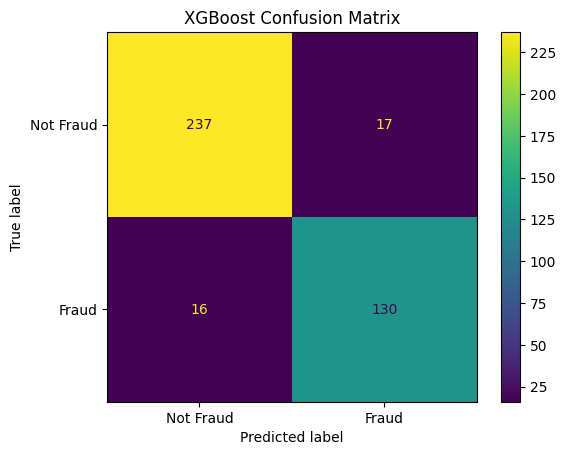

In [6]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Not Fraud", "Fraud"]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [9]:
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Evaluation Metrics")
print("--------------------------------")
print("Precision :", round(rf_precision, 4))
print("Recall    :", round(rf_recall, 4))
print("F1-Score  :", round(rf_f1, 4))
print("ROC-AUC   :", round(rf_roc_auc, 4))

Random Forest Evaluation Metrics
--------------------------------
Precision : 0.9028
Recall    : 0.8904
F1-Score  : 0.8966
ROC-AUC   : 0.9129


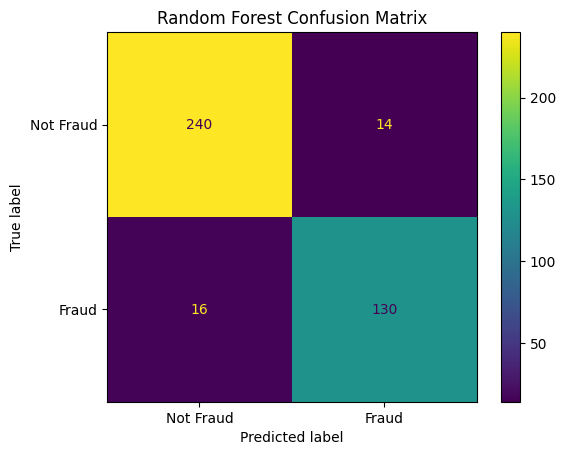

In [10]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Not Fraud", "Fraud"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [11]:
metrics_comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        rf_recall,
        xgb_recall
    ],
    "F1_Score": [
        rf_f1,
        xgb_f1
    ],
    "ROC_AUC": [
        rf_roc_auc,
        xgb_roc_auc
    ]
})

print(metrics_comparison.round(4))

           Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC
0  Random Forest    0.9250     0.9028  0.8904    0.8966   0.9129
1        XGBoost    0.9175     0.8844  0.8904    0.8874   0.9131


In [12]:
metrics_comparison.to_csv(
    "day20_metrics_comparison.csv",
    index=False
)

print("Saved: day20_metrics_comparison.csv")

Saved: day20_metrics_comparison.csv


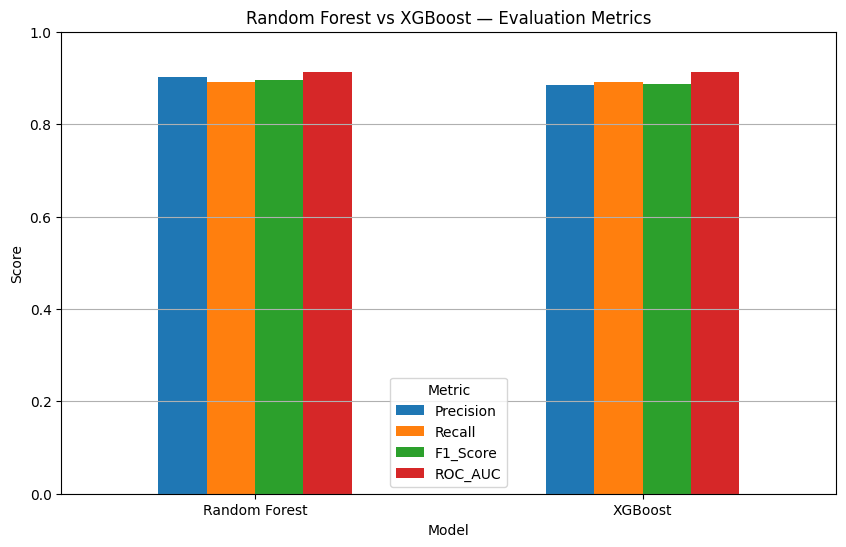

In [13]:
metrics_plot = metrics_comparison.set_index("Model")[
    ["Precision", "Recall", "F1_Score", "ROC_AUC"]
]

metrics_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Random Forest vs XGBoost — Evaluation Metrics")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y")

plt.show()

In [14]:
pd.DataFrame(
    cm_rf,
    index=["Actual Not Fraud", "Actual Fraud"],
    columns=["Predicted Not Fraud", "Predicted Fraud"]
).to_csv("day20_random_forest_confusion_matrix.csv")

pd.DataFrame(
    cm_xgb,
    index=["Actual Not Fraud", "Actual Fraud"],
    columns=["Predicted Not Fraud", "Predicted Fraud"]
).to_csv("day20_xgboost_confusion_matrix.csv")

print("Confusion matrix files saved successfully!")

Confusion matrix files saved successfully!


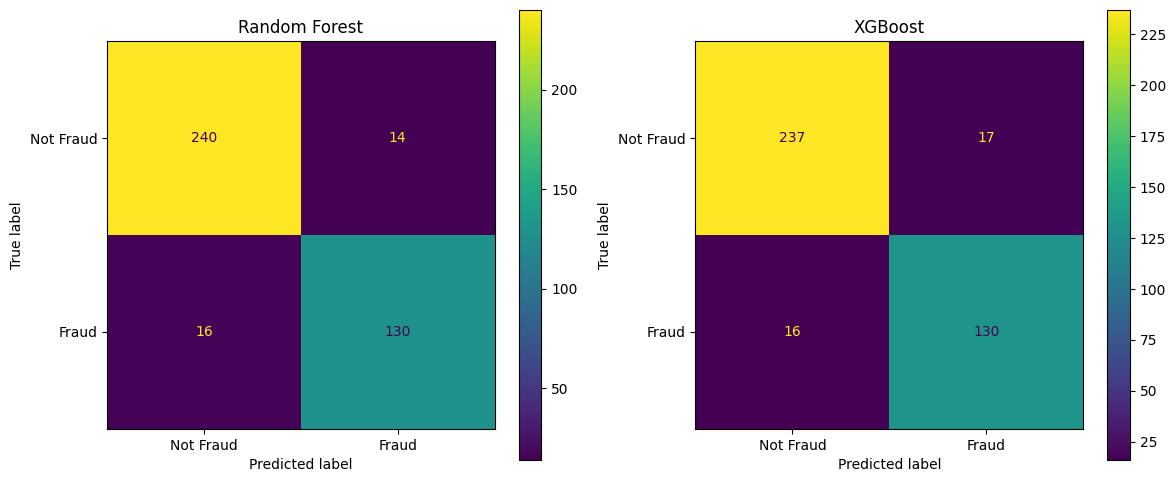

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Not Fraud", "Fraud"]
).plot(ax=axes[0])

axes[0].set_title("Random Forest")

ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Not Fraud", "Fraud"]
).plot(ax=axes[1])

axes[1].set_title("XGBoost")

plt.tight_layout()
plt.show()

## When Accuracy Becomes Misleading

Accuracy measures the percentage of total predictions that are correct.

However, accuracy can be misleading when the target classes are highly imbalanced.

### Example

Suppose a fraud detection system has 1,000 transactions:

- 990 → Not Fraud
- 10 → Fraud

If a model predicts every transaction as Not Fraud:

- Correct predictions = 990
- Total predictions = 1,000
- Accuracy = 99%

The accuracy looks excellent, but the model detects:

- 0 out of 10 fraud cases
- Fraud Recall = 0%

Therefore, a 99% accurate model can still be completely useless for fraud detection.

### Why Multiple Metrics Matter

Different metrics answer different questions:

- **Precision:** When the model predicts fraud, how often is it correct?
- **Recall:** How many actual fraud cases does the model detect?
- **F1-score:** How well does the model balance precision and recall?
- **ROC-AUC:** How well can the model distinguish between the two classes across different classification thresholds?
- **Confusion Matrix:** Shows the exact numbers of correct predictions and errors.

### Fraud Detection

For fraud detection, recall is especially important because a false negative means that an actual fraudulent transaction was not detected.

Therefore, production ML systems should not rely on accuracy alone. The evaluation metric should be selected according to the business problem and the cost of different types of errors.

## Final Model Evaluation Analysis

### Metrics Comparison

| Metric | Random Forest | XGBoost | Better |
|---|---:|---:|---|
| Accuracy | 92.50% | 91.75% | Random Forest |
| Precision | 90.28% | 88.44% | Random Forest |
| Recall | 89.04% | 89.04% | Tie |
| F1-Score | 89.66% | 88.74% | Random Forest |
| ROC-AUC | 91.29% | 91.31% | XGBoost |

### Model Strengths

#### Random Forest

Random Forest performed better in this experiment for:
- Accuracy
- Precision
- F1-score

It also produced fewer false positives:
- Random Forest: 14
- XGBoost: 17

Both models detected 130 actual fraud cases and missed 16 fraud cases.

#### XGBoost

XGBoost achieved:
- 91.75% accuracy
- 88.44% precision
- 89.04% recall
- 88.74% F1-score
- 91.31% ROC-AUC

XGBoost had a slightly higher ROC-AUC than Random Forest (91.31% vs 91.29%), although the difference was very small.

### Overall Conclusion

For this synthetic fraud-detection experiment, Random Forest performed slightly better overall because it achieved higher accuracy, precision, and F1-score.

However, both models achieved the same recall of 89.04%, meaning they detected the same proportion of actual fraud cases.

The results demonstrate why machine-learning systems should be evaluated using multiple metrics rather than accuracy alone.

The choice of metric depends on the business problem. In fraud detection, recall is particularly important because false negatives represent fraudulent transactions that were not detected.

### Key Learning

Accuracy tells us how many predictions were correct overall, but it does not tell us whether the model is correctly identifying the important minority class.

Precision, recall, F1-score, ROC-AUC, and confusion matrices provide a more complete understanding of model quality.

Therefore:

**Good ML evaluation is not just about getting a high accuracy score — it is about understanding the types and consequences of the model's errors.**